In [23]:
import json, pandas as pd, numpy as np

OSMI_PATH = 'osmi-survey-2016_1479139902.json'
WHO_PATH  = 'b23d20bb-3eae-46c1-b757-3eaa35e8ba86.csv'

with open(OSMI_PATH, 'r', encoding='utf-8') as f:
    osmi_json = json.load(f)

who_raw = pd.read_csv(WHO_PATH)


In [24]:
print(list(osmi_json.keys())); print(osmi_json['responses'][0].keys())
who_raw.head()


['stats', 'questions', 'responses']
dict_keys(['completed', 'token', 'metadata', 'hidden', 'answers'])


,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,...,FactValueUoM,FactValueNumericLowPrefix,FactValueNumericLow,FactValueNumericHighPrefix,FactValueNumericHigh,Value,FactValueTranslationID,FactComments,Language,DateModified
0,SDGSUICIDE,Crude suicide rates (per 100 000 population),text,AMR,Americas,Country,VCT,Saint Vincent and the Grenadines,Year,2021,...,NaN,NaN,0.00,NaN,0.00,0.0 [0.0-0.0],NaN,NaN,EN,2025-01-09T11:00:00.000Z
1,SDGSUICIDE,Crude suicide rates (per 100 000 population),text,EMR,Eastern Mediterranean,Country,OMN,Oman,Year,2021,...,NaN,NaN,0.12,NaN,0.34,0.2 [0.1-0.3],NaN,NaN,EN,2025-01-09T11:00:00.000Z
2,SDGSUICIDE,Crude suicide rates (per 100 000 population),text,EMR,Eastern Mediterranean,Country,PSE,"occupied Palestinian territory, including east...",Year,2021,...,NaN,NaN,0.14,NaN,0.36,0.2 [0.1-0.4],NaN,NaN,EN,2025-01-09T11:00:00.000Z
3,SDGSUICIDE,Crude suicide rates (per 100 000 population),text,EMR,Eastern Mediterranean,Country,JOR,Jordan,Year,2021,...,NaN,NaN,0.18,NaN,0.43,0.3 [0.2-0.4],NaN,NaN,EN,2025-01-09T11:00:00.000Z
4,SDGSUICIDE,Crude suicide rates (per 100 000 population),text,EMR,Eastern Mediterranean,Country,KWT,Kuwait,Year,2021,...,NaN,NaN,0.25,NaN,0.39,0.3 [0.2-0.4],NaN,NaN,EN,2025-01-09T11:00:00.000Z


In [7]:
import pandas as pd
import json

# Preview OSMI JSON safely
with open('osmi-survey-2016_1479139902.json', 'r', encoding='utf-8') as f:
    raw = json.load(f)

# Show just the first response dictionary flattened one level
print("OSMI JSON top-level keys:", list(raw.keys()))
print("\nFirst response preview:\n")
first_resp = raw['responses'][0]
for k, v in first_resp.items():
    print(f"{k}: {str(v)[:120]}")

# Preview WHO CSV
who_raw = pd.read_csv('b23d20bb-3eae-46c1-b757-3eaa35e8ba86.csv')
who_raw.head()


OSMI JSON top-level keys: ['stats', 'questions', 'responses']

First response preview:

completed: 1
token: bbd31ae24e49278ea4f395cc2e4eb18b
metadata: {'browser': 'default', 'platform': 'other', 'date_land': '2016-03-14 13:54:17', 'date_submit': '2016-03-14 14:00:36', 'u
hidden: []
answers: {'yesno_18065319': '0', 'list_18065482_choice': '26-100', 'yesno_18065487': '1', 'list_18065507_choice': 'Not eligible f


,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,...,FactValueUoM,FactValueNumericLowPrefix,FactValueNumericLow,FactValueNumericHighPrefix,FactValueNumericHigh,Value,FactValueTranslationID,FactComments,Language,DateModified
0,SDGSUICIDE,Crude suicide rates (per 100 000 population),text,AMR,Americas,Country,VCT,Saint Vincent and the Grenadines,Year,2021,...,NaN,NaN,0.00,NaN,0.00,0.0 [0.0-0.0],NaN,NaN,EN,2025-01-09T11:00:00.000Z
1,SDGSUICIDE,Crude suicide rates (per 100 000 population),text,EMR,Eastern Mediterranean,Country,OMN,Oman,Year,2021,...,NaN,NaN,0.12,NaN,0.34,0.2 [0.1-0.3],NaN,NaN,EN,2025-01-09T11:00:00.000Z
2,SDGSUICIDE,Crude suicide rates (per 100 000 population),text,EMR,Eastern Mediterranean,Country,PSE,"occupied Palestinian territory, including east...",Year,2021,...,NaN,NaN,0.14,NaN,0.36,0.2 [0.1-0.4],NaN,NaN,EN,2025-01-09T11:00:00.000Z
3,SDGSUICIDE,Crude suicide rates (per 100 000 population),text,EMR,Eastern Mediterranean,Country,JOR,Jordan,Year,2021,...,NaN,NaN,0.18,NaN,0.43,0.3 [0.2-0.4],NaN,NaN,EN,2025-01-09T11:00:00.000Z
4,SDGSUICIDE,Crude suicide rates (per 100 000 population),text,EMR,Eastern Mediterranean,Country,KWT,Kuwait,Year,2021,...,NaN,NaN,0.25,NaN,0.39,0.3 [0.2-0.4],NaN,NaN,EN,2025-01-09T11:00:00.000Z


In [8]:
!pip install pycountry
import json, pandas as pd, numpy as np, sqlite3, pycountry


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 34.0 MB/s eta 0:00:00


In [9]:
OSMI_PATH = 'osmi-survey-2016_1479139902.json'

with open(OSMI_PATH, 'r', encoding='utf-8', errors='ignore') as f:
    osmi_obj = json.load(f)

assert isinstance(osmi_obj, dict) and 'responses' in osmi_obj, "Unexpected JSON structure"
responses = osmi_obj['responses']
len(responses)


1433

In [10]:
rows = []
for r in responses:
    a = r.get('answers', {})
    rows.append({
        # country (prefer WORK country; fall back to LIVE)
        'country_work': a.get('dropdown_18069205') or a.get('dropdown_18069141'),

        # benefits signals (we'll combine these below)
        'benefit_yesno':     a.get('yesno_18065896'),        # '1' or '0'
        'benefit_coverage':  a.get('list_18065507_choice'),  # 'Yes'/'No'/...
        'benefit_options':   a.get('list_18065687_choice'),  # 'Yes'/'No'/...

        # comfort with supervisor
        'comfort_supervisor': a.get('list_18065778_choice'), # 'Yes'/'No'/'Maybe'

        # negative consequences with employer (stigma)
        'stigma_employer':    a.get('list_18065715_choice')  # 'Yes'/'No'/'Maybe'
    })

osmi_df = pd.DataFrame(rows)
print(osmi_df.shape)
osmi_df.head(3)


(1433, 6)


,country_work,benefit_yesno,benefit_coverage,benefit_options,comfort_supervisor,stigma_employer
0,United Kingdom,None,Not eligible for coverage / N/A,N/A,Yes,No
1,United States of America,None,No,Yes,Yes,No
2,United States of America,1,None,None,None,None


In [11]:
def recode_benefit(row):
    # Priority: explicit yes/no (1/0) → coverage yes/no → options yes/no
    if row['benefit_yesno'] in ('1', 1, True): return 1
    if row['benefit_yesno'] in ('0', 0, False): return 0

    bc = row['benefit_coverage']
    if bc == 'Yes': return 1
    if bc == 'No':  return 0

    bo = row['benefit_options']
    if bo == 'Yes': return 1
    if bo == 'No':  return 0

    # 'I am not sure', 'N/A', 'Not eligible', 'I don't know' → leave NaN
    return np.nan

def recode_comfort(x):
    return 1 if x == 'Yes' else 0 if x == 'No' else 0 if x == 'Maybe' else np.nan

def recode_stigma(x):
    return 1 if x == 'Yes' else 0 if x == 'No' else 1 if x == 'Maybe' else np.nan

osmi_df['country']                 = osmi_df['country_work']
osmi_df['benefits_offered']        = osmi_df.apply(recode_benefit, axis=1)
osmi_df['comfortable_discussing']  = osmi_df['comfort_supervisor'].map(recode_comfort)
osmi_df['perceived_stigma']        = osmi_df['stigma_employer'].map(recode_stigma)

osmi_df = osmi_df.dropna(subset=['country']).reset_index(drop=True)
osmi_df[['benefits_offered','comfortable_discussing','perceived_stigma']].describe()


,benefits_offered,comfortable_discussing,perceived_stigma
count,1198.000000,1146.000000,1146.000000
mean,0.605175,0.373473,0.617801
std,0.489017,0.483937,0.486137
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


In [12]:
def to_iso3(name):
    if not isinstance(name, str):
        return None
    fixes = {'US': 'United States', 'USA': 'United States',
             'UK': 'United Kingdom', 'Viet Nam': 'Vietnam',
             'Korea, Republic of': 'South Korea'}
    name = fixes.get(name.strip(), name.strip())
    try:
        return pycountry.countries.lookup(name).alpha_3
    except:
        return None

osmi_df['iso3'] = osmi_df['country'].apply(to_iso3)
osmi_df = osmi_df.dropna(subset=['iso3'])
osmi_df['iso3'].nunique(), osmi_df['iso3'].isna().mean()


(49, np.float64(0.0))

In [13]:
osmi_agg = (osmi_df.groupby(['iso3','country'])
            .agg(benefits_offered_pct=('benefits_offered','mean'),
                 comfortable_discussing_pct=('comfortable_discussing','mean'),
                 perceived_stigma_pct=('perceived_stigma','mean'),
                 n_respondents=('benefits_offered','count'))
            .reset_index())

for c in ['benefits_offered_pct','comfortable_discussing_pct','perceived_stigma_pct']:
    osmi_agg[c] = osmi_agg[c] * 100.0

print(len(osmi_agg))
osmi_agg.head()


49


,iso3,country,benefits_offered_pct,comfortable_discussing_pct,perceived_stigma_pct,n_respondents
0,AFG,Afghanistan,100.000000,100.000000,0.000000,2
1,ARE,United Arab Emirates,100.000000,0.000000,100.000000,1
2,ARG,Argentina,0.000000,0.000000,100.000000,1
3,AUS,Australia,47.619048,42.307692,61.538462,21
4,AUT,Austria,66.666667,0.000000,100.000000,3


In [14]:
WHO_PATH = 'b23d20bb-3eae-46c1-b757-3eaa35e8ba86.csv'
who = pd.read_csv(WHO_PATH)

who_2016 = who[(who['Period'] == 2016) & (who['Dim1'] == 'Both sexes')].copy()
# SpatialDimValueCode already holds the ISO-3 code
who_2016['iso3'] = who_2016['SpatialDimValueCode'].astype(str).str.upper()

who_clean = who_2016[['iso3','Location','FactValueNumeric']].rename(
    columns={'Location':'country_who', 'FactValueNumeric':'suicide_rate'}
)
who_clean.head()


,iso3,country_who,suicide_rate
2785,VCT,Saint Vincent and the Grenadines,0.51
2789,PSE,"occupied Palestinian territory, including east...",0.65
2790,SYR,Syrian Arab Republic,0.58
2792,ATG,Antigua and Barbuda,0.58
2796,LBN,Lebanon,0.76


In [15]:
final = osmi_agg.merge(who_clean[['iso3','suicide_rate']], on='iso3', how='left')
final['data_quality'] = final['n_respondents'].apply(lambda n: 'low_n' if n < 20 else 'ok')

print("Combined rows:", len(final)    )
final.head()


Combined rows: 49


,iso3,country,benefits_offered_pct,comfortable_discussing_pct,perceived_stigma_pct,n_respondents,suicide_rate,data_quality
0,AFG,Afghanistan,100.000000,100.000000,0.000000,2,3.47,low_n
1,ARE,United Arab Emirates,100.000000,0.000000,100.000000,1,2.38,low_n
2,ARG,Argentina,0.000000,0.000000,100.000000,1,8.41,low_n
3,AUS,Australia,47.619048,42.307692,61.538462,21,12.50,ok
4,AUT,Austria,66.666667,0.000000,100.000000,3,15.63,low_n


In [16]:
# Excel for inspection
final.to_excel('mentalhealth_suicide.xlsx', index=False)

# SQLite for a single data store
con = sqlite3.connect('mentalhealth_suicide.db')
final.to_sql('country_mental_health', con, if_exists='replace', index=False)
con.close()

print("Saved: mentalhealth_suicide.xlsx, mentalhealth_suicide.db")


Saved: mentalhealth_suicide.xlsx, mentalhealth_suicide.db


In [17]:
print(final.isna().sum())
final.describe(include='all')


iso3                          0
country                       0
benefits_offered_pct          3
comfortable_discussing_pct    7
perceived_stigma_pct          7
n_respondents                 0
suicide_rate                  0
data_quality                  0
dtype: int64


,iso3,country,benefits_offered_pct,comfortable_discussing_pct,perceived_stigma_pct,n_respondents,suicide_rate,data_quality
count,49,49,46.000000,42.000000,42.000000,49.000000,49.000000,49
unique,49,49,NaN,NaN,NaN,NaN,NaN,2
top,AFG,Afghanistan,NaN,NaN,NaN,NaN,NaN,low_n
freq,1,1,NaN,NaN,NaN,NaN,NaN,43
mean,NaN,NaN,31.196732,36.879656,62.461252,24.244898,10.971837,NaN
std,NaN,NaN,35.507743,31.402528,32.824427,106.447078,5.424811,NaN
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.380000,NaN
25%,NaN,NaN,0.000000,0.000000,47.500000,1.000000,6.830000,NaN
50%,NaN,NaN,21.111111,35.661080,59.340659,2.000000,10.490000,NaN
75%,NaN,NaN,56.857143,50.000000,100.000000,7.000000,14.160000,NaN


In [18]:
import numpy as np
import pandas as pd

# Keep countries with at least 10 respondents (change to 20 if you want stricter quality)
analysis = (
    final.query("n_respondents >= 10")
         .dropna(subset=[
             'benefits_offered_pct',
             'comfortable_discussing_pct',
             'perceived_stigma_pct',
             'suicide_rate'
         ])
         .copy()
)

print("Analysis rows:", len(analysis))
analysis[['iso3','country','n_respondents',
          'benefits_offered_pct','comfortable_discussing_pct',
          'perceived_stigma_pct','suicide_rate']].head()


Analysis rows: 9


,iso3,country,n_respondents,benefits_offered_pct,comfortable_discussing_pct,perceived_stigma_pct,suicide_rate
3,AUS,Australia,21,47.619048,42.307692,61.538462,12.50
10,CAN,Canada,62,59.677419,31.147541,65.573770,11.49
17,DEU,Germany,50,56.000000,15.909091,56.818182,12.99
23,FRA,France,13,23.076923,27.272727,63.636364,14.63
24,GBR,United Kingdom,137,43.065693,39.849624,56.390977,8.25


In [19]:
for col in ['benefits_offered_pct', 'comfortable_discussing_pct', 'perceived_stigma_pct']:
    r = analysis[col].corr(analysis['suicide_rate'])
    print(f"{col} vs suicide_rate  r = {r:.2f}")


benefits_offered_pct vs suicide_rate  r = 0.18
comfortable_discussing_pct vs suicide_rate  r = -0.39
perceived_stigma_pct vs suicide_rate  r = -0.36


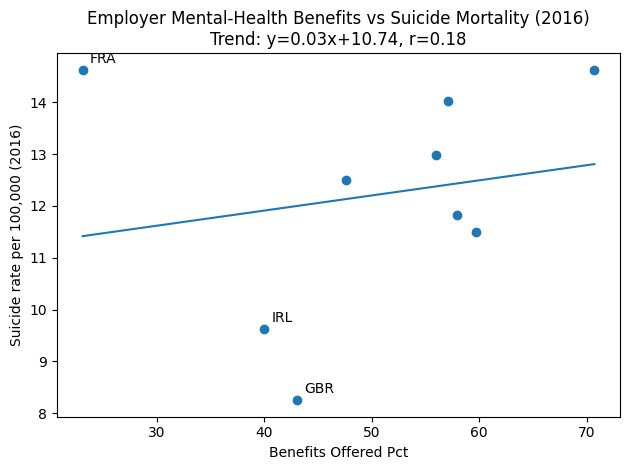

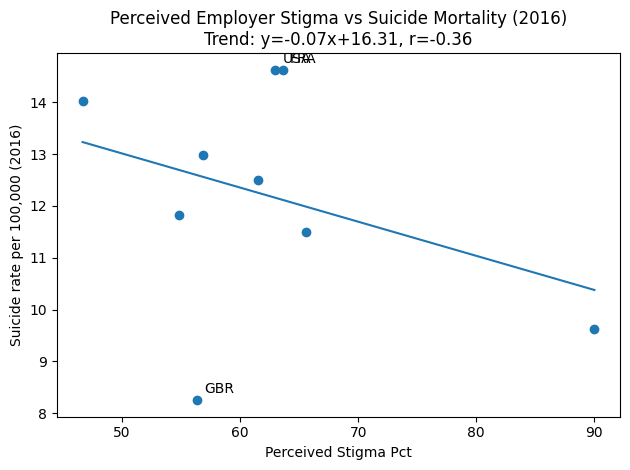

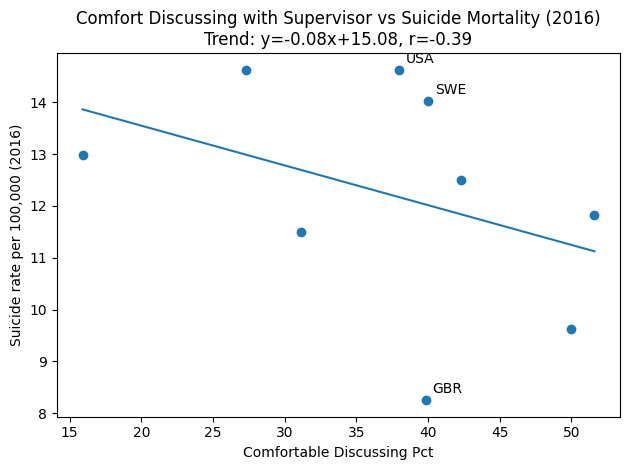

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def scatter_with_trend(df, xcol, ycol='suicide_rate', title='', outfile=None):
    x = df[xcol].values.astype(float)
    y = df[ycol].values.astype(float)

    # Fit least-squares line
    m, b = np.polyfit(x, y, 1)
    r = pd.Series(x).corr(pd.Series(y))

    plt.figure()
    plt.scatter(x, y)
    xs = np.linspace(x.min(), x.max(), 100)
    plt.plot(xs, m*xs + b)

    # Labels and title
    plt.xlabel(xcol.replace('_',' ').title())
    plt.ylabel('Suicide rate per 100,000 (2016)')
    plt.title(title + f"\nTrend: y={m:.2f}x+{b:.2f}, r={r:.2f}")

    # Annotate three biggest residual outliers with ISO-3 codes
    resid = np.abs(y - (m*x + b))
    idx = np.argsort(resid)[-3:]
    for i in idx:
        iso = df.iloc[i]['iso3']
        plt.annotate(str(iso), (x[i], y[i]), xytext=(5,5), textcoords='offset points')

    plt.tight_layout()
    if outfile:
        plt.savefig(outfile, dpi=160)
    plt.show()

# Make the two key figures
scatter_with_trend(analysis, 'benefits_offered_pct',
                   title='Employer Mental-Health Benefits vs Suicide Mortality (2016)',
                   outfile='fig_benefits_vs_suicide.png')

scatter_with_trend(analysis, 'perceived_stigma_pct',
                   title='Perceived Employer Stigma vs Suicide Mortality (2016)',
                   outfile='fig_stigma_vs_suicide.png')

# (Optional) Comfort with supervisor as a third figure
scatter_with_trend(analysis, 'comfortable_discussing_pct',
                   title='Comfort Discussing with Supervisor vs Suicide Mortality (2016)',
                   outfile='fig_comfort_vs_suicide.png')


In [21]:
analysis.to_excel('mentalhealth_suicide_clean.xlsx', index=False)
print("Saved: mentalhealth_suicide_clean.xlsx")


Saved: mentalhealth_suicide_clean.xlsx


In [22]:
analysis.sort_values('benefits_offered_pct', ascending=False)[
    ['country','benefits_offered_pct','suicide_rate']
].head(10)


,country,benefits_offered_pct,suicide_rate
45,United States of America,70.731707,14.63
10,Canada,59.677419,11.49
36,Netherlands,57.894737,11.83
44,Sweden,57.142857,14.02
17,Germany,56.000000,12.99
3,Australia,47.619048,12.50
24,United Kingdom,43.065693,8.25
29,Ireland,40.000000,9.63
23,France,23.076923,14.63
